# Guide to Loading Data from Bench2Drive

## 1. Load necessary pkl files

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load pkl files
train_infos = pickle.load(open("../data/infos/b2d_infos_train.pkl", "rb"))
val_infos = pickle.load(open("../data/infos/b2d_infos_val.pkl", "rb"))
map_infos = pickle.load(open("../data/infos/b2d_map_infos.pkl", "rb"))

print(f"Number of train samples: {len(train_infos)}")
print(f"Number of val samples: {len(val_infos)}")
print(f"Number of towns in map: {len(map_infos)}")

Number of train samples: 1455
Number of val samples: 840
Number of towns in map: 11


## 2. View structure of 1 sample

In [2]:
# Get any sample
sample_idx = 50
sample = train_infos[sample_idx]

print("Keys in 1 sample:")
for key in sample.keys():
    print(f"  {key}: {type(sample[key])}")

print("\n=== Basic Information ===")
print(f"Folder (Scene): {sample['folder']}")
print(f"Frame Index: {sample['frame_idx']}")
print(f"Town Name: {sample['town_name']}")
print(f"Ego Position: {sample['ego_translation']}")
print(f"Ego Yaw: {sample['ego_yaw']}")
print(f"Ego Velocity: {sample['ego_vel']}")
print(f"Command: {sample['command_near']}")

print("\n=== About Commands ===")
print(f"Ego Position: {sample['ego_translation']}")
print(f"command_far_xy: {sample['command_far_xy']}")
print(f"command_far: {sample['command_far']}")
print(f"command_near_xy: {sample['command_near_xy']}")
print(f"command_near: {sample['command_near']}")

Keys in 1 sample:
  folder: <class 'str'>
  town_name: <class 'str'>
  command_far_xy: <class 'numpy.ndarray'>
  command_far: <class 'int'>
  command_near_xy: <class 'numpy.ndarray'>
  command_near: <class 'int'>
  frame_idx: <class 'int'>
  ego_yaw: <class 'numpy.float64'>
  ego_translation: <class 'numpy.ndarray'>
  ego_vel: <class 'numpy.ndarray'>
  ego_accel: <class 'numpy.ndarray'>
  ego_rotation_rate: <class 'numpy.ndarray'>
  ego_size: <class 'numpy.ndarray'>
  world2ego: <class 'numpy.ndarray'>
  brake: <class 'int'>
  throttle: <class 'int'>
  steer: <class 'int'>
  sensors: <class 'dict'>
  gt_ids: <class 'numpy.ndarray'>
  gt_boxes: <class 'numpy.ndarray'>
  gt_names: <class 'numpy.ndarray'>
  num_points: <class 'numpy.ndarray'>
  npc2world: <class 'numpy.ndarray'>

=== Basic Information ===
Folder (Scene): v1/ConstructionObstacle_Town05_Route68_Weather8
Frame Index: 50
Town Name: Town05
Ego Position: [ 124.4726073  -184.64841958    0.        ]
Ego Yaw: -2.7725106914851327
E

In [ ]:
# 用這個看資料結構
import pprint
pp = pprint.PrettyPrinter(indent=4, width=80, depth=None)
pp.pprint(sample)

## 3. Load 6 camera images

In [3]:
# View sensor information
print("Sensors available in sample:")
for sensor_name in sample['sensors'].keys():
    print(f"  {sensor_name}: {type(sample['sensors'][sensor_name])}")

print()

# Get camera information
cameras = ['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 
           'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']

print("\n=== Camera Information ===")
for cam_name in cameras:
    if cam_name in sample['sensors']:
        cam_info = sample['sensors'][cam_name]
        print(f"\n{cam_name}:")
        print(f"  Data path: {cam_info['data_path']}")

Sensors available in sample:
  CAM_FRONT: <class 'dict'>
  CAM_FRONT_LEFT: <class 'dict'>
  CAM_FRONT_RIGHT: <class 'dict'>
  CAM_BACK: <class 'dict'>
  CAM_BACK_LEFT: <class 'dict'>
  CAM_BACK_RIGHT: <class 'dict'>
  LIDAR_TOP: <class 'dict'>


=== Camera Information ===

CAM_FRONT:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front/00050.jpg

CAM_FRONT_LEFT:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_left/00050.jpg

CAM_FRONT_RIGHT:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_right/00050.jpg

CAM_BACK:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back/00050.jpg

CAM_BACK_LEFT:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_left/00050.jpg

CAM_BACK_RIGHT:
  Data path: v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_right/00050.jpg


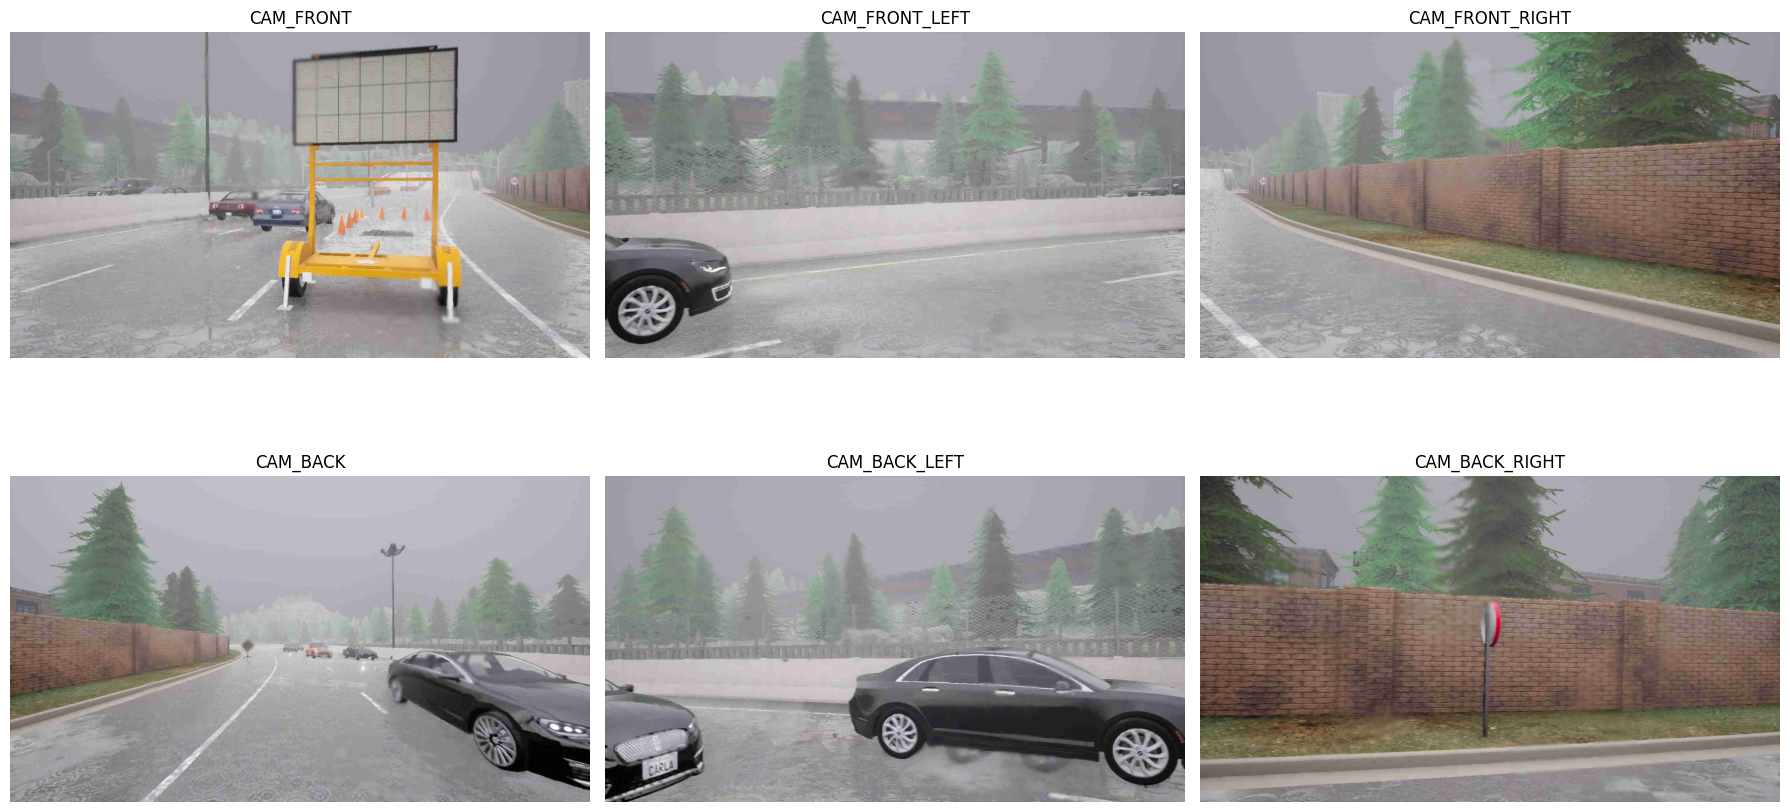

In [4]:
# Load and display 6 camera images
data_root = "../data/bench2drive"  # Adjust path according to folder structure

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cam_name in enumerate(cameras):
    if cam_name in sample['sensors']:
        cam_info = sample['sensors'][cam_name]
        img_path = os.path.join(data_root, cam_info['data_path'])
        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(cam_name)
            axes[idx].axis('off')
        except FileNotFoundError:
            axes[idx].text(0.5, 0.5, f'{cam_name}\nFile not found', 
                          ha='center', va='center')
            axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Load Trajectory Ground Truth

In [5]:
# Hàm để lấy ego trajectory (như trong dataset class)
def get_ego_trajectory(train_infos, idx, sample_rate=5, past_frames=2, future_frames=6):
    """
    Get ego vehicle trajectory
    
    Args:
        train_infos: List of samples
        idx: Current index
        sample_rate: Number of frames between each time step (default: 5)
        past_frames: Number of past frames (default: 2)
        future_frames: Number of future frames (default: 6)
    
    Returns:
        ego_his_trajs: (past_frames, 2) - Past trajectory
        ego_fut_trajs: (future_frames, 2) - Future trajectory
        ego_fut_masks: (future_frames,) - Mask for future trajectory
    """
    # Create list of indices from past to future
    adj_idx_list = range(idx - past_frames*sample_rate, 
                         idx + (future_frames+1)*sample_rate, 
                         sample_rate)
    
    cur_frame = train_infos[idx]
    full_adj_track = np.zeros((past_frames + future_frames + 1, 2))
    full_adj_mask = np.zeros(past_frames + future_frames + 1)
    
    # Transform matrix from world -> lidar (of current frame)
    world2lidar_cur = np.array(cur_frame['sensors']['LIDAR_TOP']['world2lidar'])
    
    # Load ego position at each time step
    for j, adj_idx in enumerate(adj_idx_list):
        if adj_idx < 0 or adj_idx >= len(train_infos):
            continue
        
        adj_frame = train_infos[adj_idx]
        
        # Check same scene
        if adj_frame['folder'] != cur_frame['folder']:
            continue
        
        # Get ego position in world coordinate
        ego_pos_world = np.array(adj_frame['ego_translation'])
        
        # Transform to lidar coordinate of current frame
        ego_pos_world_homo = np.concatenate([ego_pos_world, [1.0]])
        ego_pos_lidar = (world2lidar_cur @ ego_pos_world_homo)[:2]
        
        full_adj_track[j] = ego_pos_lidar
        full_adj_mask[j] = 1
    
    # Calculate offset (movement between frames)
    offset_track = full_adj_track[1:] - full_adj_track[:-1]
    
    # Accumulate offset for past trajectory (from far to near)      # 數字從小到大代表 遠的點到近的點
    ego_his_trajs = np.zeros((past_frames, 2))
    for j in range(past_frames-1, -1, -1):                          # 從 1 ~ 0 (其實就是兩個 step)
        if j == past_frames - 1:                                    # j = 1 的情況
            ego_his_trajs[j] = offset_track[j]                      # 從 current frame 到前一個 frame 的位移
        else:                                                       # j = 0 的情況
            ego_his_trajs[j] = ego_his_trajs[j+1] + offset_track[j] # 從 current frame 到前兩個 frame 的位移 (有累加喔)
    
    # Accumulate offset for future trajectory (from near to far)    # 數字從小到大代表 近的點到遠的點
    ego_fut_trajs = np.zeros((future_frames, 2))
    for j in range(past_frames, past_frames + future_frames):       # 從 2 ~ 8
        if j == past_frames:                                        
            ego_fut_trajs[j - past_frames] = offset_track[j]
        else:
            ego_fut_trajs[j - past_frames] = ego_fut_trajs[j - past_frames - 1] + offset_track[j]
    
    ego_fut_masks = full_adj_mask[past_frames+1:]                   # 暫時不知道 mask 是要幹嘛的 
    
    return ego_his_trajs, ego_fut_trajs, ego_fut_masks

# Test với sample hiện tại
ego_his, ego_fut, ego_mask = get_ego_trajectory(train_infos, sample_idx)

print("=== Ego Trajectory ===")
print(f"\nPast trajectory shape: {ego_his.shape}")
print("Past trajectory (relative positions in lidar coordinate):")
print(ego_his)

print(f"\nFuture trajectory shape: {ego_fut.shape}")
print("Future trajectory (relative positions in lidar coordinate):")
print(ego_fut)

print(f"\nFuture mask shape: {ego_mask.shape}")
print("Future mask (1 = valid, 0 = invalid):")
print(ego_mask)

=== Ego Trajectory ===

Past trajectory shape: (2, 2)
Past trajectory (relative positions in lidar coordinate):
[[ 1.14080517  7.51198447]
 [-0.07184206  3.11649823]]

Future trajectory shape: (6, 2)
Future trajectory (relative positions in lidar coordinate):
[[-0.32274626  0.08514609]
 [-0.63877894  0.36123599]
 [-0.71659508  1.34923341]
 [-0.48426127  1.47187378]
 [ 0.29309832  1.63697822]
 [ 0.73317648  1.30065783]]

Future mask shape: (6,)
Future mask (1 = valid, 0 = invalid):
[1. 1. 1. 1. 1. 1.]


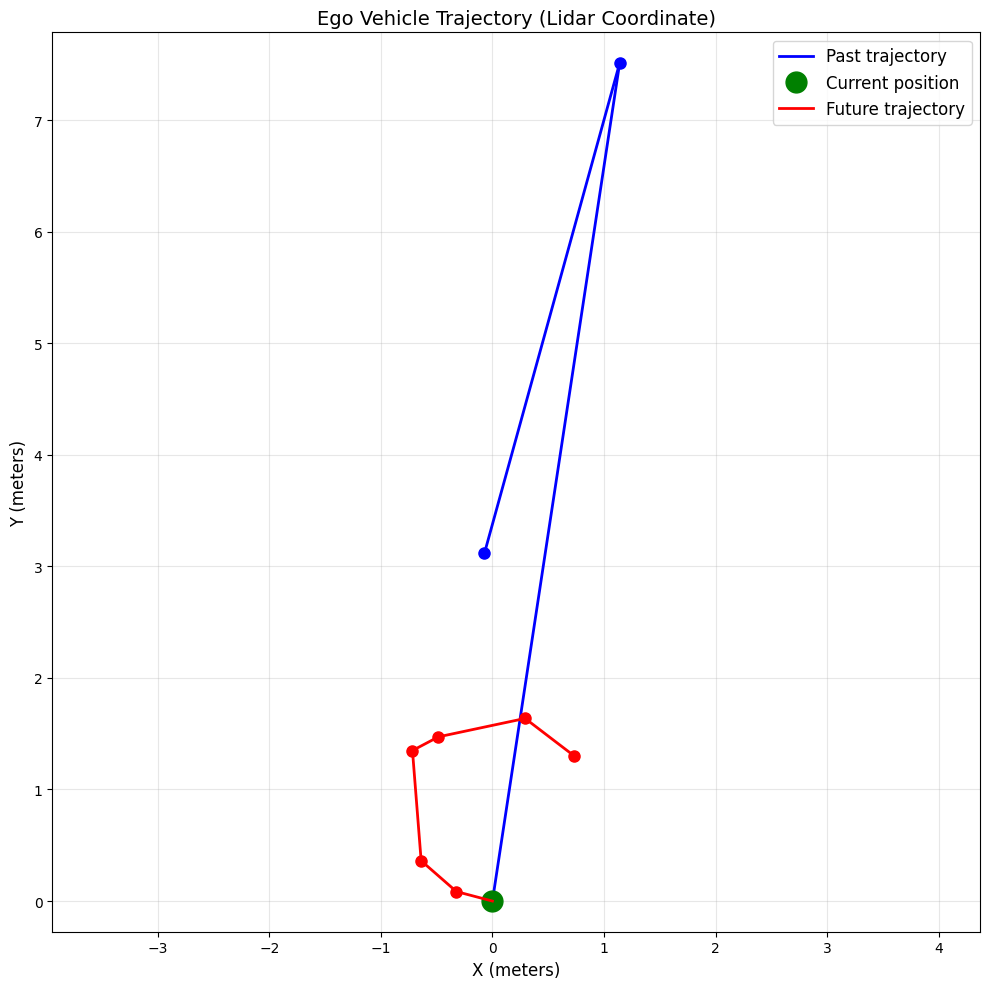


Total distance (future): 1.49 meters


In [6]:
# Visualize trajectory
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot past trajectory
for i in range(len(ego_his)):
    if i == 0:
        ax.plot([0, ego_his[i, 0]], [0, ego_his[i, 1]], 
               'b-', linewidth=2, label='Past trajectory')
    else:
        ax.plot([ego_his[i-1, 0], ego_his[i, 0]], 
               [ego_his[i-1, 1], ego_his[i, 1]], 'b-', linewidth=2)
    ax.plot(ego_his[i, 0], ego_his[i, 1], 'bo', markersize=8)

# Plot current position
ax.plot(0, 0, 'go', markersize=15, label='Current position')

# Plot future trajectory
prev_point = np.array([0, 0])
for i in range(len(ego_fut)):
    if ego_mask[i] == 1:
        if i == 0:
            ax.plot([0, ego_fut[i, 0]], [0, ego_fut[i, 1]], 
                   'r-', linewidth=2, label='Future trajectory')
        else:
            ax.plot([prev_point[0], ego_fut[i, 0]], 
                   [prev_point[1], ego_fut[i, 1]], 'r-', linewidth=2)
        ax.plot(ego_fut[i, 0], ego_fut[i, 1], 'ro', markersize=8)
        prev_point = ego_fut[i].copy()

ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_title('Ego Vehicle Trajectory (Lidar Coordinate)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

print(f"\nTotal distance (future): {np.linalg.norm(ego_fut[-1]):.2f} meters")

## 5. Load Object Bounding Boxes and Trajectories

In [7]:
# View object information in scene
print("=== Object Information ===")
print(f"Number of objects: {len(sample['gt_boxes'])}")
print(f"\nGT boxes shape: {sample['gt_boxes'].shape}")
print("Format: [x, y, z, width, length, height, yaw, vx, vy]")

# Filter objects with points
mask = sample['num_points'] != 0
valid_boxes = sample['gt_boxes'][mask]
valid_names = sample['gt_names'][mask]
valid_ids = sample['gt_ids'][mask]

print(f"\nObjects with points > 0: {len(valid_boxes)}")
print("\nInformation of objects:")
for i in range(min(5, len(valid_boxes))):  # Display first 5 objects
    box = valid_boxes[i]
    print(f"\nObject {i}:")
    print(f"  Class: {valid_names[i]}")
    print(f"  ID: {valid_ids[i]}")
    print(f"  Position (x,y,z): ({box[0]:.2f}, {box[1]:.2f}, {box[2]:.2f})")
    print(f"  Size (w,l,h): ({box[3]:.2f}, {box[4]:.2f}, {box[5]:.2f})")
    print(f"  Yaw: {box[6]:.2f}")
    print(f"  Velocity (vx,vy): ({box[7]:.2f}, {box[8]:.2f})")

=== Object Information ===
Number of objects: 26

GT boxes shape: (26, 9)
Format: [x, y, z, width, length, height, yaw, vx, vy]

Objects with points > 0: 23

Information of objects:

Object 0:
  Class: vehicle.lincoln.mkz_2020
  ID: 339
  Position (x,y,z): (-14.35, 29.45, -0.44)
  Size (w,l,h): (1.84, 4.89, 1.49)
  Yaw: 0.35
  Velocity (vx,vy): (-2.65, -7.35)

Object 1:
  Class: vehicle.nissan.patrol_2021
  ID: 338
  Position (x,y,z): (-11.22, 27.80, -0.20)
  Size (w,l,h): (2.15, 5.57, 2.05)
  Yaw: 0.34
  Velocity (vx,vy): (-2.77, -7.81)

Object 2:
  Class: vehicle.nissan.patrol_2021
  ID: 343
  Position (x,y,z): (2.90, 73.37, 0.88)
  Size (w,l,h): (2.15, 5.57, 2.05)
  Yaw: 0.37
  Velocity (vx,vy): (-0.00, -0.00)

Object 3:
  Class: vehicle.lincoln.mkz_2020
  ID: 332
  Position (x,y,z): (1.90, -40.37, -2.04)
  Size (w,l,h): (1.84, 4.89, 1.49)
  Yaw: -3.49
  Velocity (vx,vy): (-2.52, 6.92)

Object 4:
  Class: vehicle.mini.cooper_s_2021
  ID: 331
  Position (x,y,z): (-2.13, -25.27, -1.54

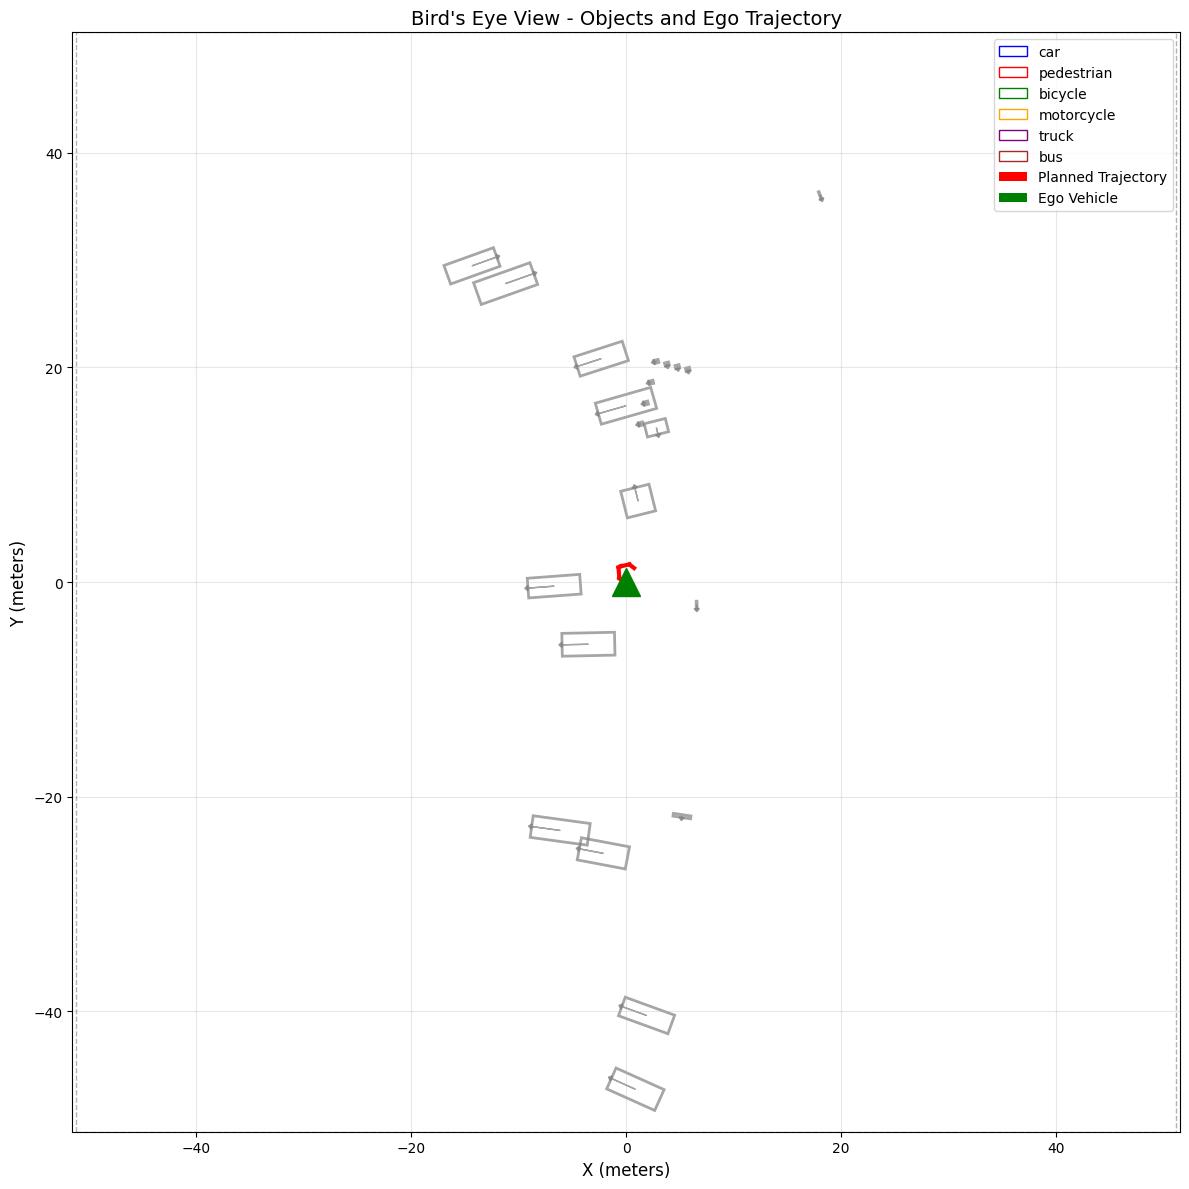

In [37]:
# Visualize BEV (Bird's Eye View) with boxes and ego trajectory
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot detection range
range_x = 51.2  # point_cloud_range
range_y = 51.2
ax.plot([-range_x, range_x, range_x, -range_x, -range_x],
        [-range_y, -range_y, range_y, range_y, -range_y],
        'k--', linewidth=1, alpha=0.3, label='Detection Range')

# Plot bounding boxes
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D
import matplotlib.patches as mpatches

colors = {'car': 'blue', 'pedestrian': 'red', 'bicycle': 'green', 
          'motorcycle': 'orange', 'truck': 'purple', 'bus': 'brown'}

for i in range(len(valid_boxes)):
    box = valid_boxes[i]
    name = valid_names[i]
    
    x, y, z, w, l, h, yaw, vx, vy = box
    
    # Create rectangle
    rect = Rectangle((-l/2, -w/2), l, w, 
                     linewidth=2, edgecolor=colors.get(name, 'gray'),
                     facecolor='none', alpha=0.7)
    
    # Rotate and translate
    t = Affine2D().rotate(yaw).translate(x, y) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)
    
    # Plot heading direction
    heading_length = l / 2
    dx = heading_length * np.cos(yaw)
    dy = heading_length * np.sin(yaw)
    ax.arrow(x, y, dx, dy, head_width=0.5, head_length=0.3,
            fc=colors.get(name, 'gray'), ec=colors.get(name, 'gray'), alpha=0.7)

# Plot ego trajectory
prev_point = np.array([0, 0])
for i in range(len(ego_fut)):
    if ego_mask[i] == 1:
        ax.plot([prev_point[0], ego_fut[i, 0]], 
               [prev_point[1], ego_fut[i, 1]], 'r-', linewidth=3)
        prev_point = ego_fut[i].copy()

# Plot ego vehicle
ax.plot(0, 0, 'g^', markersize=20, label='Ego Vehicle')

# Legend
legend_elements = [mpatches.Patch(facecolor='none', edgecolor=c, label=n) 
                   for n, c in colors.items()]
legend_elements.append(mpatches.Patch(facecolor='red', label='Planned Trajectory'))
legend_elements.append(mpatches.Patch(facecolor='green', label='Ego Vehicle'))
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_title('Bird\'s Eye View - Objects and Ego Trajectory', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(-range_x, range_x)
ax.set_ylim(-range_y, range_y)
plt.tight_layout()
plt.show()

## 6. Load Map Information (Lane Lines, Traffic Lights, Stop Signs)

In [38]:
# View map_infos structure
print("Towns in map_infos:")
for town_name in map_infos.keys():
    print(f"  {town_name}")

# Get map info of current town
town_name = sample['town_name']
map_info = map_infos[town_name]

print(f"\n=== Map Info for {town_name} ===")
print(f"Keys: {map_info.keys()}")
print(f"\nNumber of lane lines: {len(map_info['lane_points'])}")
print(f"Number of trigger volumes: {len(map_info['trigger_volumes_points'])}")

# View details of 1 lane line
if len(map_info['lane_points']) > 0:
    print("\n--- Example Lane Line ---")
    lane_idx = 0
    print(f"Lane type: {map_info['lane_types'][lane_idx]}")
    print(f"Lane points shape: {map_info['lane_points'][lane_idx].shape}")
    print(f"Lane sample points shape: {map_info['lane_sample_points'][lane_idx].shape}")
    print(f"First 3 points:\n{map_info['lane_points'][lane_idx][:3]}")

Towns in map_infos:

Town11

Town07

Town02

Town06

...

--- Example Lane Line ---

Lane type: Broken

Lane points shape: (1072, 3)

Lane sample points shape: (23, 3)

First 3 points:
[[17.17151519  2.74248502  0.        ]
 [17.12151595  2.74236295  0.        ]
 [17.07151481  2.74224135  0.        ]]

In [39]:
# Filter map elements within 50m around ego
world2lidar = np.array(sample['sensors']['LIDAR_TOP']['world2lidar'])
ego_xy = np.linalg.inv(world2lidar)[0:2, 3]
max_distance = 50

# Map element types
map_element_class = {
    'Broken': 0,        # Broken lane line
    'Solid': 1,         # Solid lane line
    'SolidSolid': 2,    # Double solid line
    'Center': 3,        # Center line
    'TrafficLight': 4,  # Traffic light
    'StopSign': 5       # Stop sign
}

# Collect nearby lane lines
nearby_lanes = []
nearby_lane_types = []

for idx in range(len(map_info['lane_sample_points'])):
    sample_points = map_info['lane_sample_points'][idx]
    distance = np.linalg.norm(sample_points[:, 0:2] - ego_xy, axis=-1)
    
    if distance.min() < max_distance:
        # Transform to lidar coordinate
        lane_points_world = map_info['lane_points'][idx]
        lane_points_homo = np.concatenate([
            lane_points_world,
            np.ones((len(lane_points_world), 1))
        ], axis=-1)
        lane_points_lidar = (world2lidar @ lane_points_homo.T).T[:, :2]
        
        nearby_lanes.append(lane_points_lidar)
        nearby_lane_types.append(map_info['lane_types'][idx])

# Collect nearby trigger volumes (traffic lights, stop signs)
nearby_triggers = []
nearby_trigger_types = []

for idx in range(len(map_info['trigger_volumes_sample_points'])):
    sample_points = map_info['trigger_volumes_sample_points'][idx]
    distance = np.linalg.norm(sample_points[:, 0:2] - ego_xy, axis=-1)
    
    if distance.min() < max_distance:
        trigger_points_world = map_info['trigger_volumes_points'][idx]
        trigger_points_homo = np.concatenate([
            trigger_points_world,
            np.ones((len(trigger_points_world), 1))
        ], axis=-1)
        trigger_points_lidar = (world2lidar @ trigger_points_homo.T).T[:, :2]
        
        nearby_triggers.append(trigger_points_lidar)
        nearby_trigger_types.append(map_info['trigger_volumes_types'][idx])

print(f"Found {len(nearby_lanes)} nearby lane lines")
print(f"Found {len(nearby_triggers)} nearby triggers")

# Count by type
from collections import Counter
lane_type_counts = Counter(nearby_lane_types)
trigger_type_counts = Counter(nearby_trigger_types)

print("\nLane types:")
for lane_type, count in lane_type_counts.items():
    print(f"  {lane_type}: {count}")

print("\nTrigger types:")
for trigger_type, count in trigger_type_counts.items():
    print(f"  {trigger_type}: {count}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

## 7. Tóm tắt - Cách Load Toàn Bộ Data

### Các bước chính:

1. **Load files pkl**:
   - `train_infos = pickle.load(open("infos/b2d_infos_train.pkl", "rb"))`
   - `val_infos = pickle.load(open("infos/b2d_infos_val.pkl", "rb"))`
   - `map_infos = pickle.load(open("infos/map_info.pkl", "rb"))`

2. **Lấy 1 sample**: `sample = train_infos[idx]`

3. **Load 6 camera images**:
   ```python
   cameras = ['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
              'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']
   for cam in cameras:
       img_path = sample['sensors'][cam]['data_path']
       img = Image.open(img_path)
   ```

4. **Load ego trajectory**:
   - Past trajectory: frames từ (idx - past_frames*sample_rate) đến idx
   - Future trajectory: frames từ idx đến (idx + future_frames*sample_rate)
   - Transform về lidar coordinate của frame hiện tại

5. **Load object bounding boxes**:
   ```python
   gt_boxes = sample['gt_boxes']  # (N, 9): [x,y,z,w,l,h,yaw,vx,vy]
   gt_names = sample['gt_names']   # Class names
   gt_ids = sample['gt_ids']       # Object IDs
   ```

6. **Load map elements**:
   ```python
   town_name = sample['town_name']
   map_info = map_infos[town_name]
   lanes = map_info['lane_points']
   triggers = map_info['trigger_volumes_points']
   ```

## 8. Helper Function - Load Complete Sample Data

In [ ]:
def load_complete_sample(train_infos, map_infos, idx, 
                        data_root="../../",
                        past_frames=2, future_frames=6, sample_rate=5):
    """
    Load complete data of 1 sample
    
    Returns:
        dict: {
            'sample_info': dict - Basic information
            'images': dict - 6 camera images
            'ego_trajectory': dict - Past and future trajectory
            'objects': dict - Bounding boxes
            'map_elements': dict - Lane lines, triggers
        }
    """
    sample = train_infos[idx]
    
    # 1. Load basic info
    sample_info = {
        'folder': sample['folder'],
        'frame_idx': sample['frame_idx'],
        'town_name': sample['town_name'],
        'ego_translation': sample['ego_translation'],
        'ego_yaw': sample['ego_yaw'],
        'ego_vel': sample['ego_vel'],
        'command': sample['command_near']
    }
    
    # 2. Load camera images
    cameras = ['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
               'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']
    images = {}
    for cam_name in cameras:
        if cam_name in sample['sensors']:
            cam_info = sample['sensors'][cam_name]
            img_path = os.path.join(data_root, cam_info['data_path'])
            try:
                images[cam_name] = np.array(Image.open(img_path))
            except FileNotFoundError:
                images[cam_name] = None
    
    # 3. Load ego trajectory
    ego_his, ego_fut, ego_mask = get_ego_trajectory(
        train_infos, idx, sample_rate, past_frames, future_frames
    )
    ego_trajectory = {
        'past': ego_his,
        'future': ego_fut,
        'future_mask': ego_mask
    }
    
    # 4. Load objects
    mask = sample['num_points'] != 0
    objects = {
        'boxes': sample['gt_boxes'][mask],  # (N, 9)
        'names': sample['gt_names'][mask],
        'ids': sample['gt_ids'][mask]
    }
    
    # 5. Load map elements
    town_name = sample['town_name']
    map_info = map_infos[town_name]
    world2lidar = np.array(sample['sensors']['LIDAR_TOP']['world2lidar'])
    ego_xy = np.linalg.inv(world2lidar)[0:2, 3]
    max_distance = 50
    
    # Filter nearby lanes
    nearby_lanes = []
    nearby_lane_types = []
    for i in range(len(map_info['lane_sample_points'])):
        sample_points = map_info['lane_sample_points'][i]
        distance = np.linalg.norm(sample_points[:, 0:2] - ego_xy, axis=-1)
        if distance.min() < max_distance:
            lane_points_world = map_info['lane_points'][i]
            lane_points_homo = np.concatenate([
                lane_points_world,
                np.ones((len(lane_points_world), 1))
            ], axis=-1)
            lane_points_lidar = (world2lidar @ lane_points_homo.T).T[:, :2]
            nearby_lanes.append(lane_points_lidar)
            nearby_lane_types.append(map_info['lane_types'][i])
    
    # Filter nearby triggers
    nearby_triggers = []
    nearby_trigger_types = []
    for i in range(len(map_info['trigger_volumes_sample_points'])):
        sample_points = map_info['trigger_volumes_sample_points'][i]
        distance = np.linalg.norm(sample_points[:, 0:2] - ego_xy, axis=-1)
        if distance.min() < max_distance:
            trigger_points_world = map_info['trigger_volumes_points'][i]
            trigger_points_homo = np.concatenate([
                trigger_points_world,
                np.ones((len(trigger_points_world), 1))
            ], axis=-1)
            trigger_points_lidar = (world2lidar @ trigger_points_homo.T).T[:, :2]
            nearby_triggers.append(trigger_points_lidar)
            nearby_trigger_types.append(map_info['trigger_volumes_types'][i])
    
    map_elements = {
        'lanes': nearby_lanes,
        'lane_types': nearby_lane_types,
        'triggers': nearby_triggers,
        'trigger_types': nearby_trigger_types
    }
    
    return {
        'sample_info': sample_info,
        'images': images,
        'ego_trajectory': ego_trajectory,
        'objects': objects,
        'map_elements': map_elements
    }

# Test function
print("Loading complete sample data...")
data = load_complete_sample(train_infos, map_infos, sample_idx)

print("\n=== Loaded Data Summary ===")
print(f"Scene: {data['sample_info']['folder']}")
print(f"Frame: {data['sample_info']['frame_idx']}")
print(f"Number of camera images: {len([v for v in data['images'].values() if v is not None])}")
print(f"Ego trajectory shape: past={data['ego_trajectory']['past'].shape}, future={data['ego_trajectory']['future'].shape}")
print(f"Number of objects: {len(data['objects']['boxes'])}")
print(f"Number of lane lines: {len(data['map_elements']['lanes'])}")
print(f"Number of triggers: {len(data['map_elements']['triggers'])}")

## 9. Calculate number of Samples and Valid Samples

In [8]:
# Analyze dataset structure
def analyze_dataset_structure(data_infos, name="Dataset"):
    """
    Analyze structure of scenes and frames in dataset
    """
    print(f"\n{'='*60}")
    print(f"  {name} Structure Analysis")
    print(f"{'='*60}")
    
    # Group by scene/folder
    from collections import defaultdict
    scene_frames = defaultdict(list)
    
    for idx, info in enumerate(data_infos):
        scene_frames[info['folder']].append(idx)
    
    # Statistics
    total_frames = len(data_infos)
    num_scenes = len(scene_frames)
    frames_per_scene = [len(frames) for frames in scene_frames.values()]
    
    print(f"\n📊 Basic Statistics:")
    print(f"  Total frames: {total_frames:,}")
    print(f"  Number of scenes: {num_scenes}")
    print(f"  Average frames per scene: {np.mean(frames_per_scene):.1f}")
    print(f"  Min frames per scene: {np.min(frames_per_scene)}")
    print(f"  Max frames per scene: {np.max(frames_per_scene)}")
    
    # Show first few scenes
    print(f"\n🎬 First 10 scenes:")
    for i, (scene_name, frame_indices) in enumerate(list(scene_frames.items())[:10]):
        print(f"  {i+1}. {scene_name}: {len(frame_indices)} frames (idx {frame_indices[0]}-{frame_indices[-1]})")
    
    # Group by town
    town_scenes = defaultdict(list)
    for scene_name in scene_frames.keys():
        town = scene_name.split('_')[0]  # Extract town name (e.g., Town01)
        town_scenes[town].append(scene_name)
    
    print(f"\n🏙️ Towns distribution:")
    for town, scenes in sorted(town_scenes.items()):
        total_frames_in_town = sum(len(scene_frames[s]) for s in scenes)
        print(f"  {town}: {len(scenes)} scenes, {total_frames_in_town:,} frames")
    
    return scene_frames, town_scenes

# Analyze train and val datasets
train_scene_frames, train_town_scenes = analyze_dataset_structure(train_infos, "Training Set")
val_scene_frames, val_town_scenes = analyze_dataset_structure(val_infos, "Validation Set")


  Training Set Structure Analysis

📊 Basic Statistics:
  Total frames: 1,455
  Number of scenes: 6
  Average frames per scene: 242.5
  Min frames per scene: 164
  Max frames per scene: 349

🎬 First 10 scenes:
  1. v1/ConstructionObstacle_Town05_Route68_Weather8: 207 frames (idx 0-206)
  2. v1/ParkedObstacle_Town10HD_Route371_Weather7: 164 frames (idx 207-370)
  3. v1/DynamicObjectCrossing_Town02_Route13_Weather6: 214 frames (idx 371-584)
  4. v1/HardBreakRoute_Town01_Route30_Weather3: 293 frames (idx 585-877)
  5. v1/VehicleTurningRoute_Town15_Route443_Weather1: 228 frames (idx 878-1105)
  6. v1/AccidentTwoWays_Town12_Route1444_Weather0: 349 frames (idx 1106-1454)

🏙️ Towns distribution:
  v1/AccidentTwoWays: 1 scenes, 349 frames
  v1/ConstructionObstacle: 1 scenes, 207 frames
  v1/DynamicObjectCrossing: 1 scenes, 214 frames
  v1/HardBreakRoute: 1 scenes, 293 frames
  v1/ParkedObstacle: 1 scenes, 164 frames
  v1/VehicleTurningRoute: 1 scenes, 228 frames

  Validation Set Structure Ana

In [ ]:
# Tính toán số lượng valid samples
def count_valid_samples(data_infos, queue_length=4, sample_interval=5, 
                       past_frames=2, future_frames=6):
    """
    Tính số lượng samples hợp lệ dựa trên logic của dataset class
    
    Một sample được coi là hợp lệ nếu:
    1. Có đủ past frames (queue_length frames trước đó)
    2. Có đủ future frames (future_frames frames sau đó)
    3. Tất cả frames đều trong cùng 1 scene (folder)
    """
    print(f"\n{'='*60}")
    print(f"  Valid Samples Analysis")
    print(f"{'='*60}")
    print(f"\nParameters:")
    print(f"  queue_length: {queue_length}")
    print(f"  sample_interval: {sample_interval}")
    print(f"  past_frames: {past_frames}")
    print(f"  future_frames: {future_frames}")
    
    total_samples = len(data_infos)
    valid_samples = 0
    invalid_past = 0
    invalid_future = 0
    invalid_both = 0
    
    valid_indices = []
    
    for idx in range(total_samples):
        cur_frame = data_infos[idx]
        cur_folder = cur_frame['folder']
        
        # Check past frames (queue)
        past_start_idx = idx - queue_length * sample_interval
        past_valid = True
        if past_start_idx < 0:
            past_valid = False
        else:
            for i in range(past_start_idx, idx, sample_interval):
                if i < 0 or i >= total_samples:
                    past_valid = False
                    break
                if data_infos[i]['folder'] != cur_folder:
                    past_valid = False
                    break
        
        # Check future frames
        future_end_idx = idx + future_frames * sample_interval
        future_valid = True
        if future_end_idx >= total_samples:
            future_valid = False
        else:
            for i in range(idx, future_end_idx + 1, sample_interval):
                if i >= total_samples:
                    future_valid = False
                    break
                if data_infos[i]['folder'] != cur_folder:
                    future_valid = False
                    break
        
        # Count validity
        if past_valid and future_valid:
            valid_samples += 1
            valid_indices.append(idx)
        elif not past_valid and not future_valid:
            invalid_both += 1
        elif not past_valid:
            invalid_past += 1
        elif not future_valid:
            invalid_future += 1
    
    print(f"\n📈 Results:")
    print(f"  Total samples: {total_samples:,}")
    print(f"  Valid samples: {valid_samples:,} ({100*valid_samples/total_samples:.2f}%)")
    print(f"  Invalid (past): {invalid_past:,} ({100*invalid_past/total_samples:.2f}%)")
    print(f"  Invalid (future): {invalid_future:,} ({100*invalid_future/total_samples:.2f}%)")
    print(f"  Invalid (both): {invalid_both:,} ({100*invalid_both/total_samples:.2f}%)")
    
    return valid_samples, valid_indices

# Count valid samples for train and val
train_valid, train_valid_indices = count_valid_samples(train_infos)
val_valid, val_valid_indices = count_valid_samples(val_infos)

## 10. Analyze Valid/Invalid Samples by Scene

In [ ]:
# Analyze valid samples per scene
def analyze_valid_samples_per_scene(data_infos, valid_indices, scene_frames):
    """
    Analyze number of valid samples in each scene
    """
    print(f"\n{'='*60}")
    print(f"  Valid Samples per Scene")
    print(f"{'='*60}")
    
    # Count valid samples per scene
    scene_valid_counts = {}
    valid_set = set(valid_indices)
    
    for scene_name, frame_indices in scene_frames.items():
        valid_count = sum(1 for idx in frame_indices if idx in valid_set)
        scene_valid_counts[scene_name] = {
            'total': len(frame_indices),
            'valid': valid_count,
            'invalid': len(frame_indices) - valid_count,
            'valid_ratio': valid_count / len(frame_indices) if len(frame_indices) > 0 else 0
        }
    
    # Show statistics
    print(f"\n📊 Example scenes:")
    for i, (scene_name, counts) in enumerate(list(scene_valid_counts.items())[:5]):
        print(f"  {scene_name}:")
        print(f"    Total: {counts['total']}, Valid: {counts['valid']}, "
              f"Invalid: {counts['invalid']} ({counts['valid_ratio']*100:.1f}% valid)")
    
    # Overall statistics
    all_valid_ratios = [c['valid_ratio'] for c in scene_valid_counts.values()]
    print(f"\n📈 Overall statistics:")
    print(f"  Average valid ratio per scene: {np.mean(all_valid_ratios)*100:.2f}%")
    print(f"  Min valid ratio: {np.min(all_valid_ratios)*100:.2f}%")
    print(f"  Max valid ratio: {np.max(all_valid_ratios)*100:.2f}%")
    
    return scene_valid_counts

# Analyze for both datasets
train_scene_valid = analyze_valid_samples_per_scene(train_infos, train_valid_indices, train_scene_frames)
val_scene_valid = analyze_valid_samples_per_scene(val_infos, val_valid_indices, val_scene_frames)

## 11. How to create Data Batch in Training

In [ ]:
# Simulate batch creation
def simulate_batch_creation(data_infos, valid_indices, batch_size=4, num_batches=3):
    """
    Simulate batch creation process in training
    """
    print(f"\n{'='*60}")
    print(f"  Batch Creation Simulation")
    print(f"{'='*60}")
    print(f"\nBatch size: {batch_size}")
    print(f"Number of batches to simulate: {num_batches}")
    
    # Randomly sample some valid indices
    np.random.seed(42)
    sampled_indices = np.random.choice(valid_indices, 
                                       size=min(batch_size * num_batches, len(valid_indices)), 
                                       replace=False)
    
    for batch_idx in range(num_batches):
        print(f"\n{'─'*60}")
        print(f"Batch {batch_idx + 1}:")
        print(f"{'─'*60}")
        
        batch_start = batch_idx * batch_size
        batch_end = min(batch_start + batch_size, len(sampled_indices))
        batch_indices = sampled_indices[batch_start:batch_end]
        
        for i, idx in enumerate(batch_indices):
            sample = data_infos[idx]
            print(f"\n  Sample {i+1} (idx={idx}):")
            print(f"    Scene: {sample['folder']}")
            print(f"    Frame: {sample['frame_idx']}")
            print(f"    Command: {sample['command_near']}")
            print(f"    Num objects: {len(sample['gt_boxes'])}")
            print(f"    Ego velocity: {sample['ego_vel']:.2f} m/s")
            
            # Show temporal context
            queue_length = 4
            sample_interval = 5
            past_start = idx - queue_length * sample_interval
            future_end = idx + 6 * sample_interval
            print(f"    Temporal window: [{past_start}, {idx}, {future_end}]")
            print(f"      → Uses frames: {list(range(past_start, idx, sample_interval))} (past)")
            print(f"                    [{idx}] (current)")
            print(f"                    {list(range(idx+sample_interval, future_end+1, sample_interval))} (future)")

# Simulate batch creation
simulate_batch_creation(train_infos, train_valid_indices, batch_size=4, num_batches=2)

In [ ]:
# Calculate actual batch data size
def calculate_batch_data_size():
    """
    Calculate size of 1 batch in memory
    """
    print(f"\n{'='*60}")
    print(f"  Batch Data Size Calculation")
    print(f"{'='*60}")
    
    # Giả sử các thông số
    batch_size = 4
    queue_length = 5  # 4 past + 1 current
    num_cameras = 6
    img_h, img_w = 900, 1600
    num_objects_avg = 20
    num_map_elements_avg = 50
    
    print(f"\nAssumed parameters:")
    print(f"  Batch size: {batch_size}")
    print(f"  Queue length: {queue_length} (4 past + 1 current)")
    print(f"  Number of cameras: {num_cameras}")
    print(f"  Image size: {img_h} x {img_w}")
    print(f"  Avg objects per frame: {num_objects_avg}")
    print(f"  Avg map elements: {num_map_elements_avg}")
    
    # Calculate sizes
    print(f"\n📊 Data shapes in 1 batch:")
    
    # Images: (batch, queue, cameras, channels, height, width)
    img_shape = (batch_size, queue_length, num_cameras, 3, img_h, img_w)
    img_size_mb = np.prod(img_shape) * 4 / (1024**2)  # float32 = 4 bytes
    print(f"  1. Images: {img_shape}")
    print(f"     Size: {img_size_mb:.2f} MB")
    
    # GT boxes: (batch, num_objects, 9)
    boxes_shape = (batch_size, num_objects_avg, 9)
    boxes_size_mb = np.prod(boxes_shape) * 4 / (1024**2)
    print(f"  2. GT Boxes: {boxes_shape}")
    print(f"     Size: {boxes_size_mb:.4f} MB")
    
    # GT labels: (batch, num_objects)
    labels_shape = (batch_size, num_objects_avg)
    labels_size_mb = np.prod(labels_shape) * 8 / (1024**2)  # int64 = 8 bytes
    print(f"  3. GT Labels: {labels_shape}")
    print(f"     Size: {labels_size_mb:.4f} MB")
    
    # Ego trajectories
    ego_past_shape = (batch_size, 2, 2)  # (batch, past_frames, xy)
    ego_fut_shape = (batch_size, 6, 2)   # (batch, future_frames, xy)
    ego_size_mb = (np.prod(ego_past_shape) + np.prod(ego_fut_shape)) * 4 / (1024**2)
    print(f"  4. Ego Past Trajectory: {ego_past_shape}")
    print(f"     Ego Future Trajectory: {ego_fut_shape}")
    print(f"     Size: {ego_size_mb:.4f} MB")
    
    # Map elements: (batch, num_elements, num_points, 2)
    map_shape = (batch_size, num_map_elements_avg, 20, 2)
    map_size_mb = np.prod(map_shape) * 4 / (1024**2)
    print(f"  5. Map Elements: {map_shape}")
    print(f"     Size: {map_size_mb:.4f} MB")
    
    # Can bus: (batch, queue, 18)
    canbus_shape = (batch_size, queue_length, 18)
    canbus_size_mb = np.prod(canbus_shape) * 4 / (1024**2)
    print(f"  6. Can Bus: {canbus_shape}")
    print(f"     Size: {canbus_size_mb:.4f} MB")
    
    # Total
    total_size_mb = img_size_mb + boxes_size_mb + labels_size_mb + ego_size_mb + map_size_mb + canbus_size_mb
    print(f"\n  📦 Total batch size: {total_size_mb:.2f} MB")
    print(f"  📦 Per sample: {total_size_mb/batch_size:.2f} MB")
    
    # Estimate for different batch sizes
    print(f"\n{'─'*60}")
    print(f"Memory estimation for different batch sizes:")
    print(f"{'─'*60}")
    for bs in [1, 2, 4, 8, 16]:
        total = (img_size_mb / batch_size) * bs + \
                (boxes_size_mb / batch_size) * bs + \
                (labels_size_mb / batch_size) * bs + \
                (ego_size_mb / batch_size) * bs + \
                (map_size_mb / batch_size) * bs + \
                (canbus_size_mb / batch_size) * bs
        print(f"  Batch size {bs:2d}: {total:7.2f} MB")
    
    return total_size_mb

batch_size_mb = calculate_batch_data_size()

## 12. Visualize Data Distribution

In [ ]:
# Visualize various statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Valid vs Invalid samples
ax1 = axes[0, 0]
categories = ['Train\nValid', 'Train\nInvalid', 'Val\nValid', 'Val\nInvalid']
values = [
    train_valid, 
    len(train_infos) - train_valid,
    val_valid,
    len(val_infos) - val_valid
]
colors_bar = ['green', 'red', 'green', 'red']
bars = ax1.bar(categories, values, color=colors_bar, alpha=0.7)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Valid vs Invalid Samples', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}\n({val/sum(values[:2] if i<2 else values[2:])*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

# 2. Frames per scene distribution
ax2 = axes[0, 1]
train_frames_per_scene = [len(frames) for frames in train_scene_frames.values()]
val_frames_per_scene = [len(frames) for frames in val_scene_frames.values()]
ax2.hist([train_frames_per_scene, val_frames_per_scene], 
         bins=20, label=['Train', 'Val'], alpha=0.7)
ax2.set_xlabel('Frames per Scene', fontsize=12)
ax2.set_ylabel('Number of Scenes', fontsize=12)
ax2.set_title('Distribution of Frames per Scene', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Valid ratio per scene
ax3 = axes[0, 2]
train_valid_ratios = [c['valid_ratio'] for c in train_scene_valid.values()]
val_valid_ratios = [c['valid_ratio'] for c in val_scene_valid.values()]
ax3.hist([train_valid_ratios, val_valid_ratios], 
         bins=20, label=['Train', 'Val'], alpha=0.7)
ax3.set_xlabel('Valid Ratio', fontsize=12)
ax3.set_ylabel('Number of Scenes', fontsize=12)
ax3.set_title('Distribution of Valid Ratio per Scene', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Object counts distribution
ax4 = axes[1, 0]
train_obj_counts = [len(info['gt_boxes']) for info in train_infos[:1000]]  # Sample 1000
val_obj_counts = [len(info['gt_boxes']) for info in val_infos[:1000]]
ax4.hist([train_obj_counts, val_obj_counts], 
         bins=30, label=['Train', 'Val'], alpha=0.7)
ax4.set_xlabel('Number of Objects', fontsize=12)
ax4.set_ylabel('Number of Frames', fontsize=12)
ax4.set_title('Distribution of Objects per Frame (sample 1000)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Ego velocity distribution
ax5 = axes[1, 1]
train_velocities = [info['ego_vel'] for info in train_infos[:1000]]
val_velocities = [info['ego_vel'] for info in val_infos[:1000]]
ax5.hist([train_velocities, val_velocities], 
         bins=30, label=['Train', 'Val'], alpha=0.7)
ax5.set_xlabel('Ego Velocity (m/s)', fontsize=12)
ax5.set_ylabel('Number of Frames', fontsize=12)
ax5.set_title('Distribution of Ego Velocity (sample 1000)', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Command distribution
ax6 = axes[1, 2]
from collections import Counter
train_commands = [info['command_near'] for info in train_infos[:5000]]
val_commands = [info['command_near'] for info in val_infos[:2000]]
train_cmd_counts = Counter(train_commands)
val_cmd_counts = Counter(val_commands)
cmd_labels = sorted(set(train_cmd_counts.keys()) | set(val_cmd_counts.keys()))
train_vals = [train_cmd_counts.get(cmd, 0) for cmd in cmd_labels]
val_vals = [val_cmd_counts.get(cmd, 0) for cmd in cmd_labels]
x = np.arange(len(cmd_labels))
width = 0.35
ax6.bar(x - width/2, train_vals, width, label='Train', alpha=0.7)
ax6.bar(x + width/2, val_vals, width, label='Val', alpha=0.7)
ax6.set_xlabel('Command', fontsize=12)
ax6.set_ylabel('Count', fontsize=12)
ax6.set_title('Distribution of Commands (sample)', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(cmd_labels, rotation=45, ha='right')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ All visualizations completed!")

## 13. Summary - Training Configuration

### **Important parameters:**

```python
# Dataset Configuration
queue_length = 4           # Number of past frames in temporal window
sample_interval = 5        # Distance between frames (5 frames = 0.5s @ 10Hz)
past_frames = 2           # Number of past frames for trajectory
future_frames = 6         # Number of future frames to predict (6 * 0.5s = 3s)
point_cloud_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # Detection range

# Training Configuration
batch_size = 4            # Usually 1-4 due to memory constraint
num_workers = 4           # DataLoader workers
shuffle = True            # Shuffle by group (scene)
drop_last = True          # Drop last batch if not enough size
```

### **Training Flow:**

1. **Dataset Load**: Load train_infos.pkl (all frames from all scenes)
2. **Group Flag**: Assign each scene a group ID for proper shuffle
3. **Sample Selection**: Only take valid samples (with enough past + future frames)
4. **Batch Creation**: 
   - DataLoader sample random indices
   - Each index loads temporal window (queue_length frames)
   - Transform images, augmentation
   - Load trajectories, objects, map elements
   - Collate into batch
5. **Forward Pass**: Model processes batch
6. **Loss Calculation**: 
   - Detection loss (boxes, classes)
   - Map segmentation loss (lanes, traffic lights)
   - Trajectory planning loss (future waypoints)
7. **Backward & Update**: Gradient descent

### **Memory Requirements:**

- **Single sample**: ~650 MB (with images 900x1600)
- **Batch size 4**: ~2.6 GB
- **Recommend**: RTX 3090 (24GB) or better for batch size 4-8